# Analyse du dataset — cartes de bruit (pipeline GAT)

Ce notebook explore le dataset de graphes utilisé pour entraîner le GAT. Chaque
graphe = une **carte de bruit** (`NoiseMap_*.ply`) générée pour :

- une **ville** (`map_name`) — la géométrie urbaine,
- un **drone** (`drone_id`) — la signature acoustique de la source,
- un **point source** (`drone_pos` = position `x, y, z` du drone/émetteur).

Les **nœuds** du graphe sont les **faces** du maillage ; les **arêtes** relient
les faces qui partagent une arête géométrique (adjacence spatiale). Chaque face
porte une **classe** issue de sa couleur RGB :

| classe | nom        | signification (SPL = niveau de pression acoustique) |
|:------:|:-----------|:----------------------------------------------------|
| 0 | violet    | SPL < 0 dB |
| 1 | blue      | SPL < 15 dB |
| 2 | yellow    | SPL < 25 dB |
| 3 | orange    | SPL < 35 dB |
| 4 | red       | SPL < 45 dB |
| 5 | dark_red  | SPL ≥ 45 dB |
| 6 | occluded  | face non visible depuis le drone |

**Au programme :** distribution des classes (global / ville / drone), couverture
ville×drone, **proximité entre classes** (matrice d'adjacence des arêtes),
**statistiques des points sources** (positions, hauteur), et le lien
physique distance-à-la-source ↔ classe.

> ⚙️ Le dataset fait ~8 Go (5 shards). Le notebook **streame** les shards un par
> un et n'agrège que des compteurs : l'empreinte mémoire reste faible.

## 0 — Configuration & imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import torch

# Rendre importables les modules du pipeline (config.py, dataio.py).
GAT_DIR = Path.cwd()
if (GAT_DIR / "config.py").exists():
    pass
elif (GAT_DIR.parent / "config.py").exists():           # lancé depuis ana_dataset/
    GAT_DIR = GAT_DIR.parent
else:                                                    # fallback chemin repo
    GAT_DIR = Path("/home/ldena/Bureau/PIR-local/PIR/models/GAT")
sys.path.insert(0, str(GAT_DIR))

from config import (
    RGB_TO_CLASS, NUM_CLASSES, DRONES, META, CLASS_WEIGHTS, SHARD_DIR,
)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Noms + couleurs canoniques des classes (la couleur RGB EST la sémantique).
CLASS_NAMES = ["violet", "blue", "yellow", "orange", "red", "dark_red", "occluded"]
_rgb_by_cls = {c: rgb for rgb, c in RGB_TO_CLASS.items()}
CLASS_COLORS = [tuple(v / 255 for v in _rgb_by_cls[c]) for c in range(NUM_CLASSES)]
CLASS_CMAP = mcolors.ListedColormap(CLASS_COLORS)

print(f"GAT_DIR    : {GAT_DIR}")
print(f"SHARD_DIR  : {SHARD_DIR}")
print(f"classes    : {NUM_CLASSES} -> {CLASS_NAMES}")
print(f"drones     : {DRONES}")

GAT_DIR    : /home/ldena/Bureau/PIR-local/PIR/models/GAT
SHARD_DIR  : /home/ldena/Bureau/PIR-local/PIR/dataset/data/generated/processed/shards
classes    : 7 -> ['violet', 'blue', 'yellow', 'orange', 'red', 'dark_red', 'occluded']
drones     : ['F-4', 'I2', 'M2', 'S-9']


## 1 — Lecture en streaming des shards

Un seul passage sur les shards. Pour chaque graphe on extrait :

- les **comptes de classes** (nœuds, classe -1 = inconnue/non mappée écartée),
- la **matrice d'adjacence des classes** 7×7 (paires de classes reliées par une arête),
- la **distance physique au point source** accumulée par classe (`‖centroïde − drone_pos‖`),
- les **métadonnées** : ville, drone, n_nœuds, n_arêtes, position source.

Aucun graphe n'est conservé en mémoire après traitement.

In [2]:
shard_paths = sorted(Path(SHARD_DIR).glob("shard_*.pt"))
assert shard_paths, f"Aucun shard trouvé dans {SHARD_DIR}"

records = []                                          # 1 ligne par graphe
class_totals = np.zeros(NUM_CLASSES, dtype=np.int64)  # comptes globaux
adj = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)   # paires d'arêtes
dist_sum = np.zeros(NUM_CLASSES)                      # somme dist->source / classe
dist_cnt = np.zeros(NUM_CLASSES, dtype=np.int64)
height_sum = np.zeros(NUM_CLASSES)                    # somme hauteur (z centroïde)

for sp in shard_paths:
    graphs = torch.load(sp, weights_only=False)
    for g in graphs:
        y = g.y.numpy()
        valid = y >= 0
        yv = y[valid]
        counts = np.bincount(yv, minlength=NUM_CLASSES)
        class_totals += counts

        # Adjacence des classes (arêtes dont les deux extrémités sont valides).
        ei = g.edge_index.numpy()
        ys, yd = y[ei[0]], y[ei[1]]
        m = (ys >= 0) & (yd >= 0)
        if m.any():
            np.add.at(adj, (ys[m], yd[m]), 1)

        # Distance physique au point source + hauteur, par classe.
        dpos = g.drone_pos.numpy().astype(np.float64)
        pos = g.pos.numpy().astype(np.float64)
        d = np.linalg.norm(pos - dpos[None, :], axis=1)
        np.add.at(dist_sum, yv, d[valid])
        np.add.at(height_sum, yv, pos[valid, 2])
        np.add.at(dist_cnt, yv, 1)

        x, yc, z = (float(v) for v in dpos)
        records.append({
            "map": getattr(g, "map_name", "?"),
            "drone": getattr(g, "drone_id", "?"),
            "n_nodes": int(g.num_nodes),
            "n_edges": int(ei.shape[1]),
            "n_valid": int(valid.sum()),
            "src_x": x, "src_y": yc, "src_z": z,
            **{f"c{c}": int(counts[c]) for c in range(NUM_CLASSES)},
        })
    del graphs

df = pd.DataFrame(records)
CLS_COLS = [f"c{c}" for c in range(NUM_CLASSES)]
print(f"{len(df)} graphes | {len(df['map'].unique())} villes | "
      f"{len(df['drone'].unique())} drones | {class_totals.sum():,} nœuds étiquetés")
df.head()

2050 graphes | 10 villes | 4 drones | 58,654,904 nœuds étiquetés


,map,drone,n_nodes,n_edges,n_valid,src_x,src_y,src_z,c0,c1,c2,c3,c4,c5,c6
0,ville10,F-4,18939,56510,18939,13.6871,16.866600,0.2757,9080,2818,512,88,8,1,6432
1,ville10,F-4,18939,56510,18939,14.4586,2.048600,0.6909,10808,5029,718,77,13,0,2294
2,ville10,F-4,18939,56510,18939,15.0936,6.204200,0.7644,10928,4275,707,78,12,0,2939
3,ville10,F-4,18939,56510,18939,15.5596,-17.226801,0.2565,12485,2251,439,94,8,2,3660
4,ville10,F-4,18939,56510,18939,15.8751,-10.006000,0.5347,12324,3595,628,73,11,0,2308


## 2 — Distribution globale des classes

,classe,nom,n_noeuds,pct,poids_CE
0,0,violet,"2,708,581",21.35%,0.658000
1,1,blue,"3,588,616",28.29%,0.340000
2,2,yellow,"937,643",7.39%,0.203000
3,3,orange,"264,668",2.09%,1.570000
4,4,red,"44,571",0.35%,4.048000
5,5,dark_red,"4,866",0.04%,5.708000
6,6,occluded,"5,138,391",40.50%,0.690000


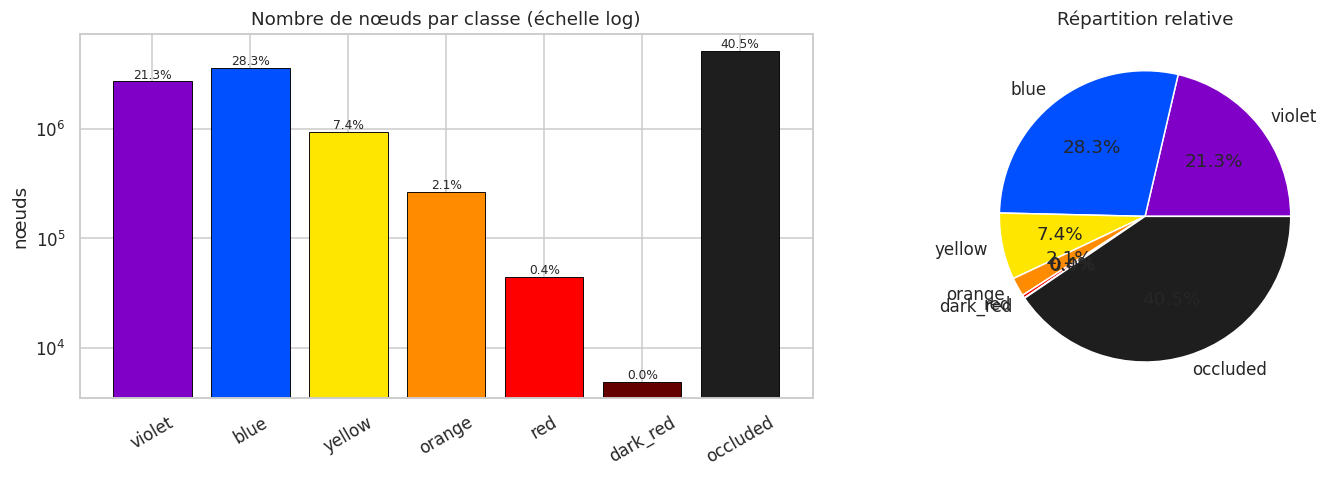

Déséquilibre max/min = 1056x  (majoritaire: occluded, minoritaire: dark_red)


In [17]:
total = class_totals.sum()
dist_tbl = pd.DataFrame({
    "classe": range(NUM_CLASSES),
    "nom": CLASS_NAMES,
    "n_noeuds": class_totals,
    "pct": 100 * class_totals / total,
})
# Poids CE utilisés à l'entraînement (rappel de config.py), pour contexte.
if CLASS_WEIGHTS is not None:
    dist_tbl["poids_CE"] = np.round(CLASS_WEIGHTS, 3)
display(dist_tbl.style.format({"n_noeuds": "{:,}", "pct": "{:.2f}%"}))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(CLASS_NAMES, class_totals, color=CLASS_COLORS, edgecolor="black", lw=.6)
ax[0].set_yscale("log")
ax[0].set_title("Nombre de nœuds par classe (échelle log)")
ax[0].set_ylabel("nœuds"); ax[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(class_totals):
    ax[0].text(i, v, f"{100*v/total:.1f}%", ha="center", va="bottom", fontsize=8)

ax[1].pie(class_totals, labels=CLASS_NAMES, colors=CLASS_COLORS,
          autopct="%1.1f%%", wedgeprops={"edgecolor": "white"})
ax[1].set_title("Répartition relative")
plt.tight_layout(); plt.show()

imb = class_totals.max() / max(class_totals.min(), 1)
print(f"Déséquilibre max/min = {imb:.0f}x  "
      f"(majoritaire: {CLASS_NAMES[class_totals.argmax()]}, "
      f"minoritaire: {CLASS_NAMES[class_totals.argmin()]})")

## 3 — Statistiques par ville

,n_graphes,n_noeuds,noeuds_moy,drones
map,,,,
ville,224,"8,925,100","39,844",4
ville8,205,"6,463,855","31,531",4
ville10,204,"3,863,556","18,939",4
ville3,204,"7,835,460","38,409",4
ville6,203,"3,525,501","17,367",4
ville2,203,"4,810,729","23,698",4
ville9,203,"5,868,933","28,911",4
ville7,202,"6,849,618","33,909",4
ville5,201,"4,609,363","22,932",4


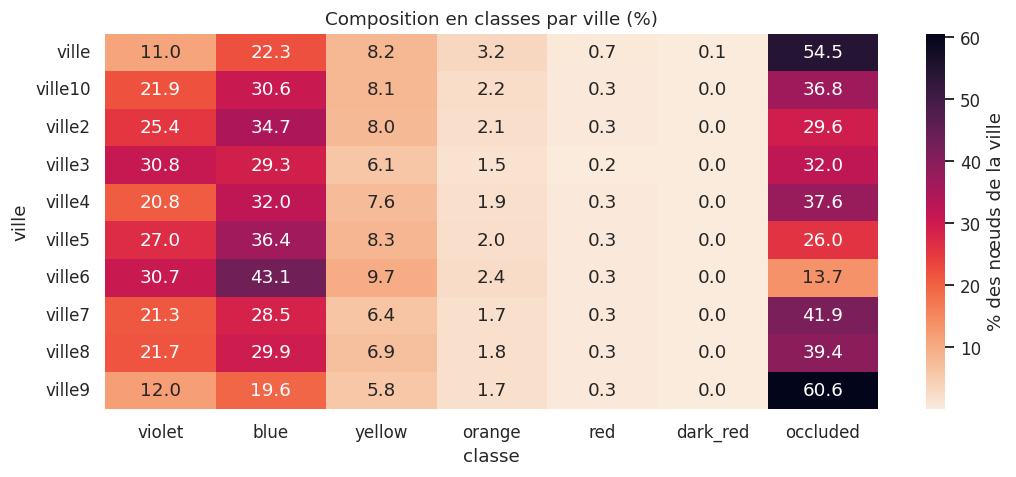

In [18]:
by_map = df.groupby("map").agg(
    n_graphes=("map", "size"),
    n_noeuds=("n_valid", "sum"),
    noeuds_moy=("n_valid", "mean"),
    drones=("drone", "nunique"),
).sort_values("n_graphes", ascending=False)
display(by_map.style.format({"n_noeuds": "{:,}", "noeuds_moy": "{:,.0f}"}))

# Distribution des classes par ville, normalisée par ligne (% de chaque classe).
city_cls = df.groupby("map")[CLS_COLS].sum()
city_pct = city_cls.div(city_cls.sum(axis=1), axis=0) * 100
city_pct.columns = CLASS_NAMES

fig, ax = plt.subplots(figsize=(10, max(4, .45 * len(city_pct))))
sns.heatmap(city_pct, annot=True, fmt=".1f", cmap="rocket_r",
            cbar_kws={"label": "% des nœuds de la ville"}, ax=ax)
ax.set_title("Composition en classes par ville (%)")
ax.set_xlabel("classe"); ax.set_ylabel("ville")
plt.tight_layout(); plt.show()

## 4 — Statistiques par drone

Les drones diffèrent par leur **puissance acoustique** (voir `LP_REF`/`META`).
Un drone plus bruyant déplace la distribution vers les classes de **SPL élevé**
(red, dark_red) ; un drone plus discret la concentre dans les bas SPL.

,n_graphes,n_noeuds,villes,pales,rpm_min,rpm_max
drone,,,,,,
F-4,507,"14,390,641",10,4,800.000000,6420.000000
I2,515,"14,761,443",10,4,3400.000000,4560.000000
M2,514,"14,772,174",10,4,907.000000,6540.000000
S-9,514,"14,730,646",10,6,3300.000000,6900.000000


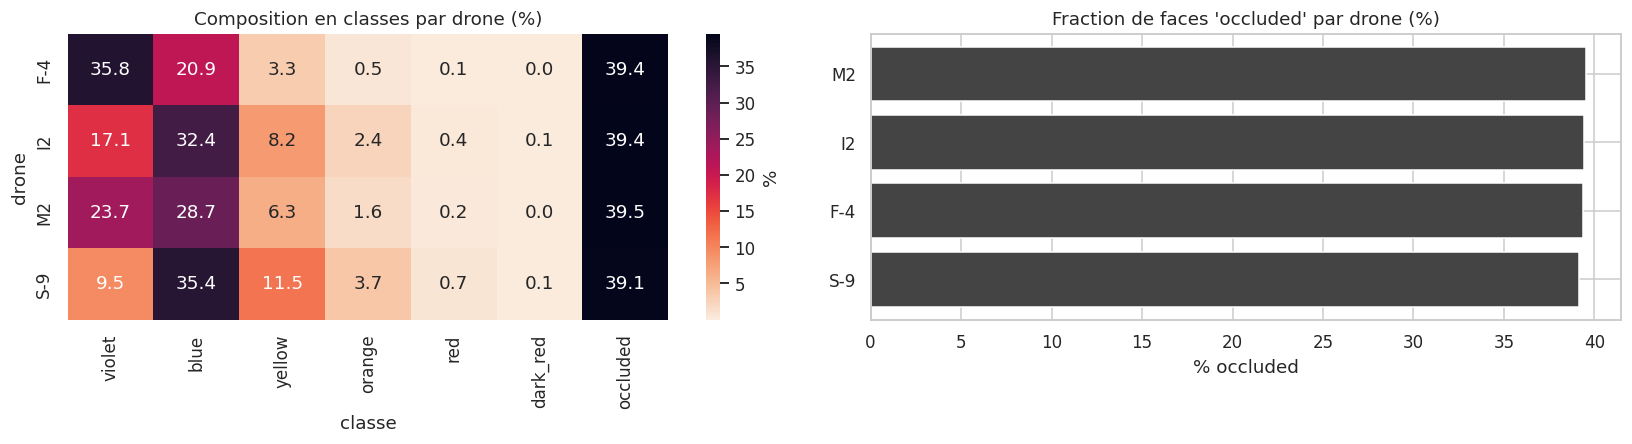

In [5]:
by_drone = df.groupby("drone").agg(
    n_graphes=("drone", "size"),
    n_noeuds=("n_valid", "sum"),
    villes=("map", "nunique"),
)
# Rappel des signatures (n_pales, rpm_min, rpm_max) depuis config.META.
by_drone["pales"] = [META.get(d, (None,)*3)[0] for d in by_drone.index]
by_drone["rpm_min"] = [META.get(d, (None,)*3)[1] for d in by_drone.index]
by_drone["rpm_max"] = [META.get(d, (None,)*3)[2] for d in by_drone.index]
display(by_drone.style.format({"n_noeuds": "{:,}"}))

drone_cls = df.groupby("drone")[CLS_COLS].sum()
drone_pct = drone_cls.div(drone_cls.sum(axis=1), axis=0) * 100
drone_pct.columns = CLASS_NAMES

fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
sns.heatmap(drone_pct, annot=True, fmt=".1f", cmap="rocket_r",
            cbar_kws={"label": "%"}, ax=ax[0])
ax[0].set_title("Composition en classes par drone (%)")
ax[0].set_xlabel("classe"); ax[0].set_ylabel("drone")

# Fraction de faces occluded par drone : sensible à la hauteur/visibilité.
occ = (drone_cls["c6"] / drone_cls.sum(axis=1) * 100).sort_values()
ax[1].barh(occ.index, occ.values, color="#444")
ax[1].set_title("Fraction de faces 'occluded' par drone (%)")
ax[1].set_xlabel("% occluded")
plt.tight_layout(); plt.show()

## 5 — Couverture ville × drone

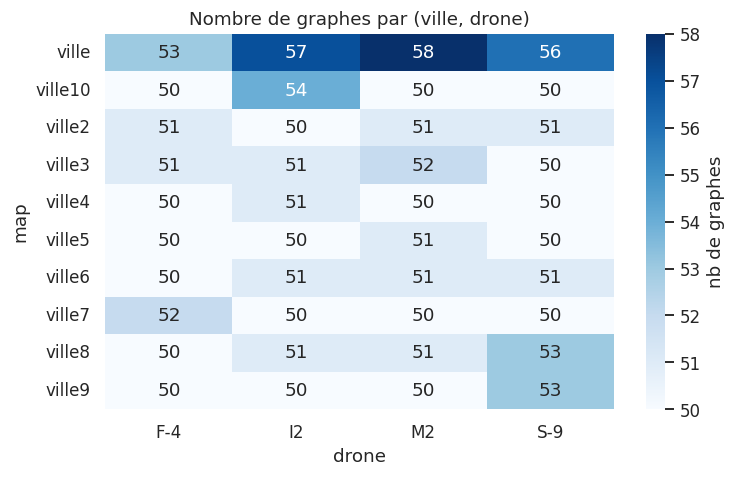

Combinaisons (ville, drone) absentes : 0 / 40


In [6]:
cov = df.pivot_table(index="map", columns="drone", values="n_nodes",
                     aggfunc="size", fill_value=0)
fig, ax = plt.subplots(figsize=(7, max(4, .45 * len(cov))))
sns.heatmap(cov, annot=True, fmt="d", cmap="Blues", ax=ax,
            cbar_kws={"label": "nb de graphes"})
ax.set_title("Nombre de graphes par (ville, drone)")
plt.tight_layout(); plt.show()
print("Combinaisons (ville, drone) absentes :",
      int((cov == 0).sum().sum()), "/", cov.size)

## 6 — Proximité entre classes (adjacence des arêtes)

C'est la question « la classe 1 est-elle souvent voisine de la classe 6 ? ».

On compte, sur **toutes les arêtes** du dataset, les paires de classes reliées.
Trois lectures complémentaires :

1. **Co-occurrence brute** (symétrique) — quelles paires partagent le plus d'arêtes.
2. **P(voisin = j | classe = i)** — pour une face de classe *i*, la répartition
   des classes de ses voisines (normalisé par ligne).
3. **Lift** = co-occurrence observée / attendue sous indépendance. >1 ⇒ les deux
   classes se touchent **plus** que le hasard ne le prédirait (frontières
   physiques récurrentes), <1 ⇒ elles s'évitent.

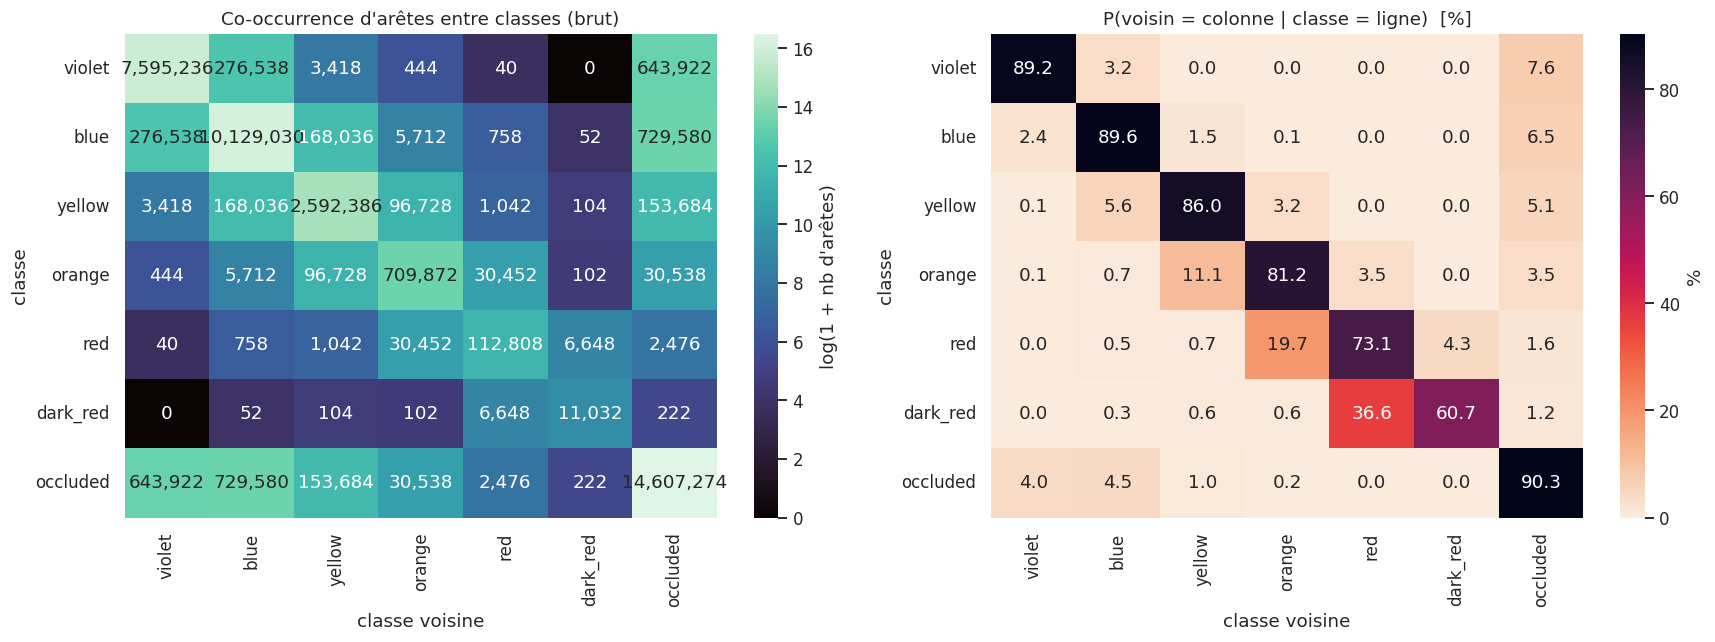

In [19]:
adj_sym = adj + adj.T          # rendre symétrique (arêtes non orientées)
np.fill_diagonal(adj_sym, np.diag(adj))   # éviter de doubler la diagonale
labels = CLASS_NAMES

# 1) co-occurrence (log pour lisibilité) + 2) conditionnelle par ligne
row_cond = adj_sym / adj_sym.sum(axis=1, keepdims=True).clip(min=1) * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(np.log1p(adj_sym), annot=adj_sym, fmt=",d", cmap="mako",
            xticklabels=labels, yticklabels=labels, ax=ax[0],
            cbar_kws={"label": "log(1 + nb d'arêtes)"})
ax[0].set_title("Co-occurrence d'arêtes entre classes (brut)")

sns.heatmap(row_cond, annot=True, fmt=".1f", cmap="rocket_r",
            xticklabels=labels, yticklabels=labels, ax=ax[1],
            cbar_kws={"label": "%"})
ax[1].set_title("P(voisin = colonne | classe = ligne)  [%]")
for a in ax:
    a.set_xlabel("classe voisine"); a.set_ylabel("classe")
plt.tight_layout(); plt.show()

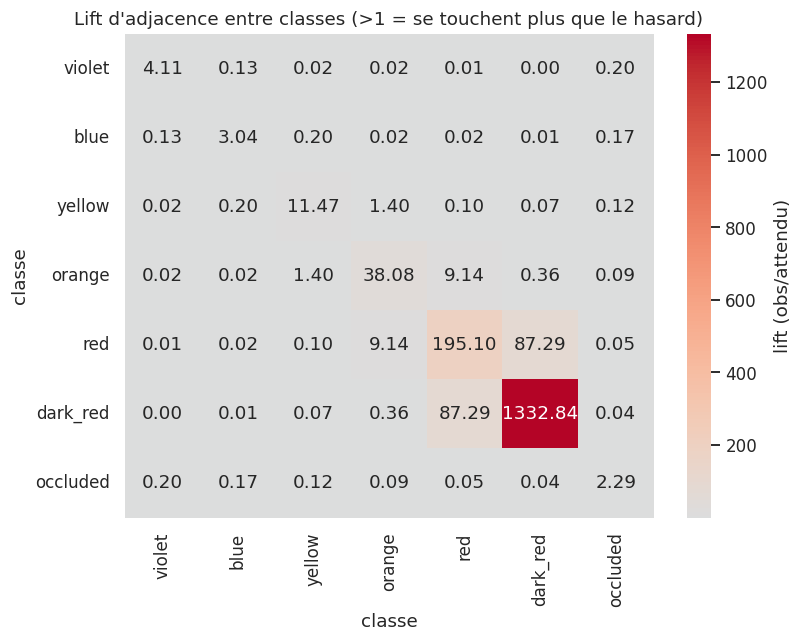

Top paires de classes voisines (hors même classe) :
       blue ↔ occluded  :  3,553,752 arêtes   (lift 0.17)
     violet ↔ occluded  :  3,107,592 arêtes   (lift 0.20)
     violet ↔ blue      :  1,535,882 arêtes   (lift 0.13)
       blue ↔ yellow    :    818,888 arêtes   (lift 0.20)
     yellow ↔ occluded  :    678,722 arêtes   (lift 0.12)
     yellow ↔ orange    :    414,900 arêtes   (lift 1.40)
     orange ↔ occluded  :    145,694 arêtes   (lift 0.09)
     orange ↔ red       :    135,886 arêtes   (lift 9.14)


In [8]:
# 3) Lift : observé / attendu sous indépendance des extrémités d'arête.
deg = adj_sym.sum(axis=1).astype(np.float64)        # "degré" par classe
E2 = adj_sym.sum()                                  # somme totale
expected = np.outer(deg, deg) / E2                  # attendu si indépendant
lift = adj_sym / np.where(expected > 0, expected, np.nan)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(lift, annot=True, fmt=".2f", center=1, cmap="coolwarm",
            xticklabels=labels, yticklabels=labels, ax=ax,
            cbar_kws={"label": "lift (obs/attendu)"})
ax.set_title("Lift d'adjacence entre classes (>1 = se touchent plus que le hasard)")
ax.set_xlabel("classe"); ax.set_ylabel("classe")
plt.tight_layout(); plt.show()

# Top paires inter-classes (hors diagonale).
iu = np.triu_indices(NUM_CLASSES, k=1)
pairs = sorted(
    [(adj_sym[i, j], lift[i, j], i, j) for i, j in zip(*iu)],
    reverse=True,
)
print("Top paires de classes voisines (hors même classe) :")
for n, lf, i, j in pairs[:8]:
    print(f"  {CLASS_NAMES[i]:>9} ↔ {CLASS_NAMES[j]:<9} : "
          f"{int(n):>10,} arêtes   (lift {lf:.2f})")

## 7 — Points sources (positions des drones)

Le **point source** est la position `(x, y, z)` du drone émetteur. L'échelle du
maillage est 1 unité ≈ 100 m, donc `z` est la **hauteur de vol** normalisée.

,count,mean,std,min,25%,50%,75%,max
src_x,2050.000,0.052,11.010,-19.198,-9.294,0.253,9.354,19.327
src_y,2050.000,-0.009,11.045,-19.198,-9.504,0.023,9.594,19.190
src_z,2050.000,0.703,0.747,0.200,0.393,0.596,0.807,6.995


2050 positions sources distinctes pour 2050 graphes


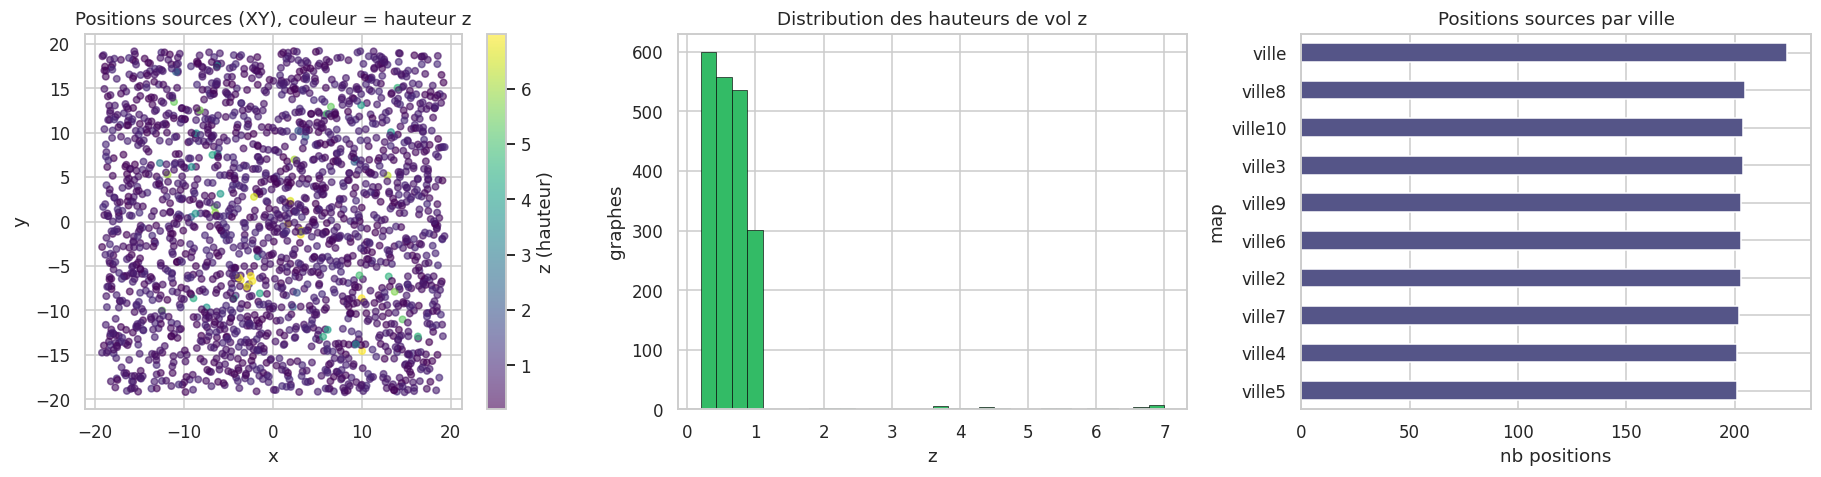

In [10]:
src = df.drop_duplicates(["map", "drone", "src_x", "src_y", "src_z"])
display(df[["src_x", "src_y", "src_z"]].describe().T.style.format("{:.3f}"))
print(f"{len(src)} positions sources distinctes pour {len(df)} graphes")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
# (a) nuage spatial XY, couleur = hauteur
sc = ax[0].scatter(df["src_x"], df["src_y"], c=df["src_z"], cmap="viridis",
                   s=18, alpha=.6)
ax[0].set(title="Positions sources (XY), couleur = hauteur z",
          xlabel="x", ylabel="y"); ax[0].set_aspect("equal", "box")
fig.colorbar(sc, ax=ax[0], label="z (hauteur)")
# (b) histogramme des hauteurs
ax[1].hist(df["src_z"], bins=30, color="#3b6", edgecolor="black", lw=.4)
ax[1].set(title="Distribution des hauteurs de vol z", xlabel="z", ylabel="graphes")
# (c) nb de points sources par ville
src.groupby("map").size().sort_values().plot.barh(ax=ax[2], color="#558")
ax[2].set(title="Positions sources par ville", xlabel="nb positions")
plt.tight_layout(); plt.show()

### 7b — Lien physique : hauteur du drone ↔ classes

Attendu acoustique : plus le drone vole **haut**, plus il « voit » de faces en
ligne directe → la fraction **occluded** baisse et le SPL moyen au sol diminue
(éloignement). On regroupe les graphes par tranche de hauteur.

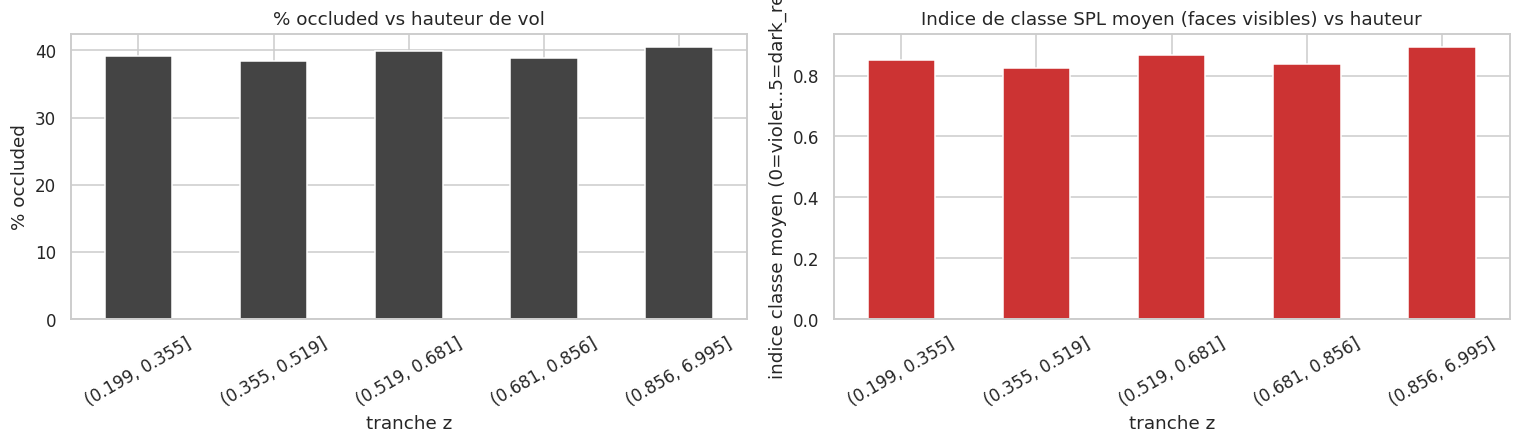

In [11]:
tmp = df.copy()
tmp["z_bin"] = pd.qcut(tmp["src_z"], q=5, duplicates="drop")
g = tmp.groupby("z_bin", observed=True)
occ_frac = g["c6"].sum() / g[CLS_COLS].sum().sum(axis=1) * 100
# "SPL moyen" approximé par l'indice de classe (0..5) des faces visibles.
vis = [f"c{c}" for c in range(6)]
spl_idx = (g[vis].sum() * np.arange(6)).sum(axis=1) / g[vis].sum().sum(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
occ_frac.plot.bar(ax=ax[0], color="#444")
ax[0].set(title="% occluded vs hauteur de vol", ylabel="% occluded", xlabel="tranche z")
ax[0].tick_params(axis="x", rotation=30)
spl_idx.plot.bar(ax=ax[1], color="#c33")
ax[1].set(title="Indice de classe SPL moyen (faces visibles) vs hauteur",
          ylabel="indice classe moyen (0=violet..5=dark_red)", xlabel="tranche z")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### 7c — Distance physique au point source, par classe

Les classes étant des **tranches de SPL**, on doit retrouver la décroissance du
son avec la distance : les classes de SPL élevé (red, dark_red) près de la
source, les bas SPL (blue, yellow) loin.

,classe,dist_moy_source,hauteur_moy
0,violet,25.918,0.911
1,blue,16.252,0.986
2,yellow,7.493,0.807
3,orange,3.611,0.798
4,red,1.570,0.662
5,dark_red,0.690,0.479
6,occluded,19.466,1.622


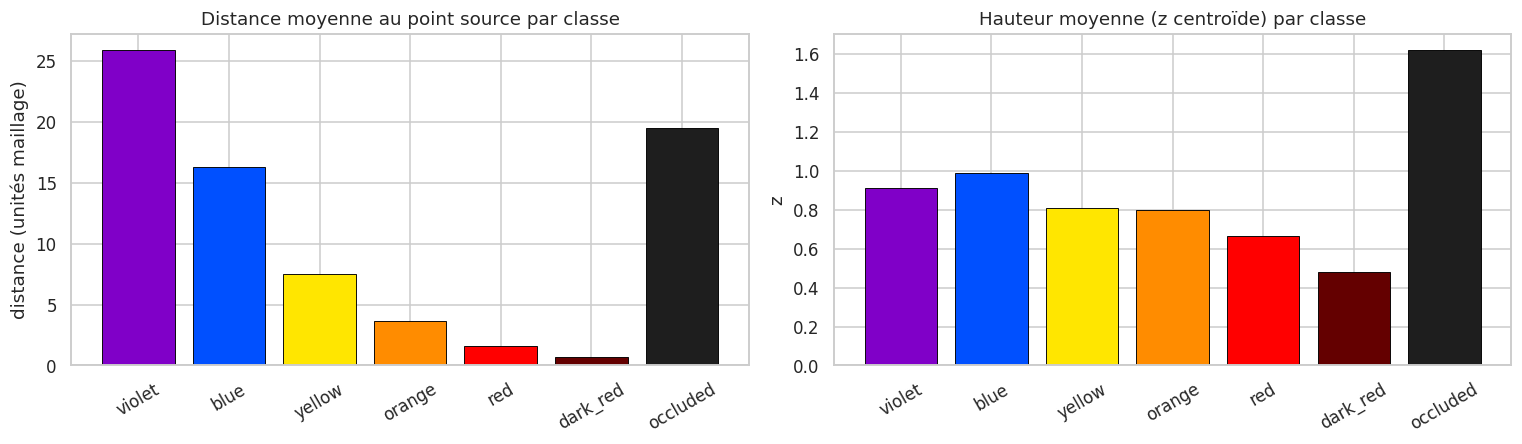

In [12]:
mean_dist = dist_sum / dist_cnt.clip(min=1)
mean_h = height_sum / dist_cnt.clip(min=1)
dd = pd.DataFrame({"classe": CLASS_NAMES,
                   "dist_moy_source": mean_dist,
                   "hauteur_moy": mean_h})
display(dd.style.format({"dist_moy_source": "{:.3f}", "hauteur_moy": "{:.3f}"}))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].bar(CLASS_NAMES, mean_dist, color=CLASS_COLORS, edgecolor="black", lw=.6)
ax[0].set(title="Distance moyenne au point source par classe", ylabel="distance (unités maillage)")
ax[0].tick_params(axis="x", rotation=30)
ax[1].bar(CLASS_NAMES, mean_h, color=CLASS_COLORS, edgecolor="black", lw=.6)
ax[1].set(title="Hauteur moyenne (z centroïde) par classe", ylabel="z")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 8 — Taille des graphes (nœuds & arêtes)

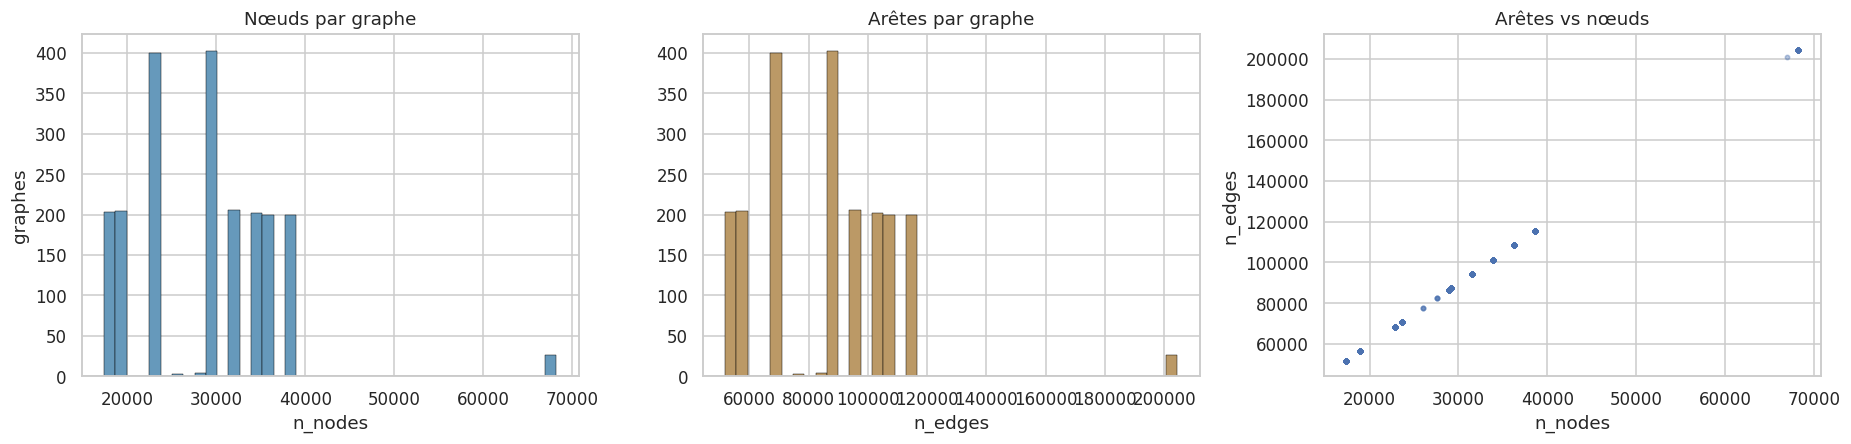

,count,mean,std,min,25%,50%,75%,max
n_nodes,"2,050","28,612","8,154","17,367","22,889","29,179","33,909","68,255"
n_edges,"2,050","85,529","24,460","51,794","68,360","87,230","101,420","204,424"
n_valid,"2,050","28,612","8,154","17,367","22,889","29,179","33,909","68,255"


degré moyen ≈ 2.99 arêtes/nœud (arêtes orientées dédupliquées)


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].hist(df["n_nodes"], bins=40, color="#69b", edgecolor="black", lw=.3)
ax[0].set(title="Nœuds par graphe", xlabel="n_nodes", ylabel="graphes")
ax[1].hist(df["n_edges"], bins=40, color="#b96", edgecolor="black", lw=.3)
ax[1].set(title="Arêtes par graphe", xlabel="n_edges")
ax[2].scatter(df["n_nodes"], df["n_edges"], s=8, alpha=.4)
ax[2].set(title="Arêtes vs nœuds", xlabel="n_nodes", ylabel="n_edges")
plt.tight_layout(); plt.show()
display(df[["n_nodes", "n_edges", "n_valid"]].describe().T.style.format("{:,.0f}"))
print(f"degré moyen ≈ {df['n_edges'].sum() / df['n_nodes'].sum():.2f} arêtes/nœud "
      f"(arêtes orientées dédupliquées)")

## 9 — Synthèse

In [14]:
print("="*64)
print(" SYNTHÈSE DU DATASET")
print("="*64)
print(f"Graphes        : {len(df):,}")
print(f"Villes         : {df['map'].nunique()}  -> {sorted(df['map'].unique())}")
print(f"Drones         : {df['drone'].nunique()}  -> {sorted(df['drone'].unique())}")
print(f"Nœuds étiquetés: {class_totals.sum():,}")
print(f"Déséquilibre   : {class_totals.max()/max(class_totals.min(),1):.0f}x "
      f"({CLASS_NAMES[class_totals.argmax()]} >> {CLASS_NAMES[class_totals.argmin()]})")
print("-"*64)
print("Classes les plus minoritaires (à surveiller pour l'entraînement) :")
order = np.argsort(class_totals)
for c in order[:3]:
    print(f"  {CLASS_NAMES[c]:>9} : {class_totals[c]:>10,}  "
          f"({100*class_totals[c]/class_totals.sum():.2f}%)")
print("-"*64)
print("Paire de classes la plus 'collée' (lift max, hors diagonale) :")
best = max(((lift[i, j], i, j) for i, j in zip(*iu)), key=lambda t: t[0])
print(f"  {CLASS_NAMES[best[1]]} ↔ {CLASS_NAMES[best[2]]}  (lift {best[0]:.2f})")
print("="*64)

 SYNTHÈSE DU DATASET
Graphes        : 2,050
Villes         : 10  -> ['ville', 'ville10', 'ville2', 'ville3', 'ville4', 'ville5', 'ville6', 'ville7', 'ville8', 'ville9']
Drones         : 4  -> ['F-4', 'I2', 'M2', 'S-9']
Nœuds étiquetés: 58,654,904
Déséquilibre   : 938x (occluded >> dark_red)
----------------------------------------------------------------
Classes les plus minoritaires (à surveiller pour l'entraînement) :
   dark_red :     24,602  (0.04%)
        red :    200,546  (0.34%)
     orange :  1,206,323  (2.06%)
----------------------------------------------------------------
Paire de classes la plus 'collée' (lift max, hors diagonale) :
  red ↔ dark_red  (lift 87.29)
